In this post, I'll be walking through an implementation of Kalman filtering and smoothing as well as prediction for a local trend model imposed on log volatility of stock returns, as an exercise and part of my own learning. 
This is based on Chapter 11 of Tsay's *Analysis of Financial Time Series (2005)*.

### A Quick Intro to State-Space Models

The state-space model assumes that there are 2 layers of reality:

1. a **hidden layer** (or state) - the true underlying state of the system which can never be directly observed
2. an **observable layer** (or measurement) - a measurement of that true hidden state which is all we can see (data we collect)

First we'll look at the most basic state-space model: the local trend model

## The Local Trend Model

$$
y_t = \mu_t + e_t, \quad e_t \sim N(0, \sigma^2_e), \tag{11.1}
$$
$$
\mu_{t+1} = \mu_t + \eta_t, \quad \eta_t \sim N(0, \sigma^2_\eta), \tag{11.2}
$$

note: this is technically a Local *Level* Model, but Tsay refers to it as Local Trend Model, so we'll stick with that naming for now.

Equation (11.1) is called the **observation equation**
- shows how our observable layer changes over time
- can see that measurements are our hidden state + measurement noise

Equation (11.2) is called the **(transition) state equation**
- models how our hidden layer evolves over time
- it's essentially VAR on the hidden state: next state = past state + transition noise (random shocks to hidden state)

In the local trend model we assume that our hidden state follows a random walk and that our observation is simply our state plus noise, but this is not a rule nor is it the best case all of the time. 

State-space models can take on many forms depending on our assumptions about the underlying dynamics of our data. 

In fact, most models in econometrics and time series (ARMA, ARIMA, VAR, etc.) can be rewritten as state-space representations, with varying state/observation equations, which I'll cover later. 

### Statistical Inference

Tsay states that there are essentially 3 different types of Inference:
\
(let $\mu_t$ = hidden state, and  $F_t = \{y_1, \dots, y_t\}$: "all data up to and including time t")

1. **Filtering** - estimating $\mu_t$ using $F_t$
    - we're at time t, and have seen everything up to t, and want to guess the current hidden state; what Kalman Filter does
2. **Prediction** - estimating $\mu_{t+h}$ using $F_t$
    - we're at time t, and have seen everything up to t, and want to forecast h steps ahead. We haven't seen past t
4. **Smoothing** - estimating $\mu_t$ using $F_T$, where $T > t$
    - we've seen the entire dataset, everything up to T, and want to go back and re-estimate what $\mu_t$ was at some earlier point; what the Kalman Smoother does
    - this always gives better estimates than filtering because we have more information

### The Kalman Filter

The Kalman Filter is an algorithm that essentially works by continually updating our state estimate (filtered estimate $\mu_{t|t}$) based on information that we get from that time step's observation (the "innovation"/forecast error $v_t = y_t - \mu_{t|t-1}$, the difference between the observed value and the predicted observation at time t) and how much we trust that new information to shift our old estimate (Kalman gain $K_t$). 

By running this algorithm we gain a few things: 

At all time steps $\{1, \ldots, T\}$:

- filtered state estimates $\mu_{t|t}$ 
- uncertainty (variance) of those filtered state estimates $\Sigma_{t|t}$ 
- "innovation"/1-step forecast errors $v_t$ 
- variance of 1-step forecast errors $V_t$ 
- Kalman Gain $K_t$ 


Kalman Filter Benefits: 

- Optimal filtering - since it's under Gaussian assumptions it's the minimum MSE estimator of the hidden state
- Real-time updating - it processes observations sequentially, so it's naturally suited for online/streaming/stock/economic data
- Missing-Value Handling - when observation values $y_t$ are not provided, the algorithm simply doesn't update the state estimate, and only runs the prediction step, continuing until there are observations again
- Foundation for smoothing - the filtered estimates are one-sided (use only past data). After filtering, the Kalman smoother runs backward and gives us better state estimates using the full sample, which is what we'd use for retrospective analysis.


- Likelihood evaluation
    - The log-likelihood for state-space models can't be directly optimized in closed form since it depends on $v_t$ and $V_t$, which are themselves outputs of the filter
    - By running the Kalman filter we get $v_t$ and $V_t$ at each step, which lets us evaluate the log-likelihood for any given ( $\sigma^2_\eta$, $\sigma^2_e$ )
    -  We can then numerically maximize over those parameters (picking values of $\sigma^2_\eta$, $\sigma^2_e$, running filter, evaluating likelihood, and repeating until it's maximized). this is called the **prediction error decomposition** of the likelihood


## Local Trend Model Kalman - Manual Implementation

For this exercise, I'll be implementing a Kalman filter on the log of the realized volatility of Alcoa stock from January 2, 2003 to May 7, 2004.

### Step 1: Defining the State-Space Model

Before we can implement the Kalman Filter, we need to define what state-space model represents the data best. 

For this example, Tsay has kindly given us empirically that the data follows an ARIMA(0,1,1) and the assumption that the state-space model is local trend.


However, in practice, the workflow would look something like this: 

1) Import and inspect the data (trend, seasonality, stationarity--adf,kpss tests)
2) Fit multiple standard Time Series Models and pick the best one (fit -> evaluate AIC/BIC -> inspect/test residuals)
3) Once we have our best model, convert to state-space form so we can apply the Kalman Filter (in this example, Tsay uses a trick to convert ARIMA(0,1,1) to a local level model, but for a general case we'd use one of Akaike's, Harvey's, or Aoki's methods)
4) Use the prediction error decomposition to estimate parameters via MLE. In general this means numerically maximizing the likelihood directly in state-space form. In this example Tsay shortcuts this by estimating ARIMA parameters with MLE first, then converting to state-space parameters analytically (doesn't work in all cases however)
5) Run the Kalman Filter (forward recursion)
6) Run the Kalman Smoother (backward recursion), using the full sample $\{1, \ldots, T\}$ to get improved retrospective state estimates $\mu_{t|T}$


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA # for fitting ARIMA models
from datetime import datetime, timedelta
from time import time

In [2]:
alcoa = pd.read_csv("alcoa_log_rv.csv", index_col = 0, parse_dates = True)
print(alcoa.shape)
alcoa.head(10)


(340, 1)


,x
2003-01-02,1.245451
2003-01-03,1.422385
2003-01-06,0.192602
2003-01-07,0.627168
2003-01-08,2.405115
2003-01-09,1.163619
2003-01-10,1.760922
2003-01-13,0.785726
2003-01-14,0.954357
2003-01-15,1.779349


In [3]:
# explictly set frequency to business days
alcoa = alcoa.asfreq('B')
print(pd.infer_freq(alcoa.index))


print(alcoa.x.isna().sum())  # how many NaNs?
print(alcoa.x.isna().mean()) # what fraction?

B
12
0.03409090909090909


In [4]:
alcoa = alcoa.dropna()

alcoa.shape

(340, 1)

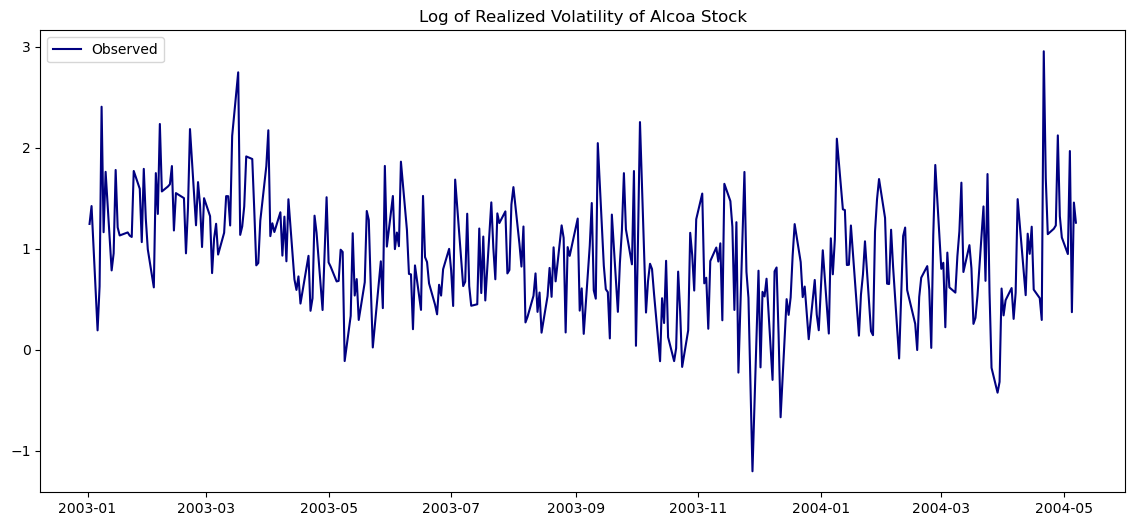

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

# observed
ax.plot(alcoa.index, alcoa['x'], color='navy', label='Observed', alpha=1)

ax.set_title("Log of Realized Volatility of Alcoa Stock")
ax.legend()
plt.show()

In [6]:
# define model
arima_011 = ARIMA(alcoa, order = (0,1,1))

/Users/calebwilliams/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/calebwilliams/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/calebwilliams/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [7]:
# fit the model
start = time()
arima_011_fit = arima_011.fit()
end = time()
print('Model Fitting Time', end - start)

Model Fitting Time 0.031241893768310547


In [8]:
# summary of model
print(arima_011_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      x   No. Observations:                  340
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -258.975
Date:                Fri, 29 May 2026   AIC                            521.950
Time:                        20:52:25   BIC                            529.602
Sample:                             0   HQIC                           525.000
                                - 340                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8582      0.033    -26.102      0.000      -0.923      -0.794
sigma2         0.2688      0.016     16.723      0.000       0.237       0.300
Ljung-Box (L1) (Q):                   2.10   Jarque-

In [9]:
theta_hat = 0.8582          
sigma_a_hat = np.sqrt(0.2688)

print(theta_hat)
print(sigma_a_hat)

0.8582
0.5184592558726288


So our ARIMA(0,1,1) model can be written as

$$(1− B)y_t = (1− 0.858B)a_t, $$
$$\hat{\sigma_a} = 0.5184$$
(integrated MA(1))

How we believe the system looks: 
$$
y_t = \mu_t + e_t, \quad e_t \sim N(0, \sigma^2_e)
$$
$$
\mu_{t+1} = \mu_t + \eta_t, \quad \eta_t \sim N(0, \sigma^2_\eta)
$$

But we have no way of directly observing $\sigma^2_e$ or $\sigma^2_\eta$

However, we can and have gotten $\hat{\sigma_a}$ $\hat{\theta_a}$ by fitting ARIMA(0,1,1) on our data $y_t$

We know that since state-space and ARIMA(0,1,1) are describing the same data, there must be a mathematical equivalence where we can solve for $\sigma^2_e$ and $\sigma^2_\eta$

That relationship is given as: 
$$ \sigma^2_\eta + 2\sigma^2_e = (1 + \theta^2)\sigma^2_a $$ 
$$ \sigma^2_e = \theta\sigma^2_a $$ 


In [10]:
# Solving for our state-space parameters: 

sigma_e_squared = theta_hat*sigma_a_hat**2
sigma_eta_squared = ((1 + theta_hat**2) * sigma_a_hat**2) - 2*sigma_e_squared

print(sigma_e_squared)
print(sigma_eta_squared)

0.23068415999999992
0.005404826111999994


In [11]:
sigma_e   = np.sqrt(sigma_e_squared)
sigma_eta = np.sqrt(sigma_eta_squared)

print(sigma_e)
print(sigma_eta)

0.480295908789571
0.07351752248273873


Now we have our state-space parameters $\hat{\sigma^2_e}$ and $\hat{\sigma^2_\eta}$

Notice what each tells us about our data:

- $\hat{\sigma_e} = 0.480$
- $\hat{\sigma_\eta} = 0.0735$

$\hat{\sigma_e}$ is nearly 6 times larger than $\hat{\sigma_\eta}$!

This means that the true underlying volatility $\mu_t$ moves about 0.07 units/day on average, but our observation is off by about 0.48 units just from measurement noise. 

So, on any given day, a big move in log realized volatility is *mostly noise*, not real change in underlying volatility. 


### Step 2: Implementing the Kalman Filter

Now that we've estimated the parameters for our local trend model, we have all the components needed to be used in the Kalman Filter, and can move on to actually running the filter. 

Our local-trend model:

$$
y_t = \mu_t + e_t, \quad e_t \sim N(0, \sigma^2_e)
$$
$$
\mu_{t+1} = \mu_t + \eta_t, \quad \eta_t \sim N(0, \sigma^2_\eta)
$$

where

- $\sigma^2_{e} = 0.23068$
- $\sigma^2_\eta = 0.00540$


The Kalman Filter Algorithm for a local trend model is as follows: 

At each time step t we run 7 equations in order:

$$ v_t = y_t - \mu_{t|t-1} \tag{compute innovation/forecast error}$$ 

$$ V_t = \Sigma_{t|t-1} + \sigma^2_e \tag{compute innovation variance}$$ 

$$ K_t = \frac{\Sigma_{t|t-1}}{V_t} \tag{Kalman Gain}$$ 

$$ \mu_{t|t} = \mu_{t|t-1}  + K_tv_t \tag{update state estimate}$$ 

$$ \Sigma_{t|t} = \Sigma_{t|t-1}(1 - K_t) \tag{update state uncertainty}$$ 



$$ \mu_{t+1|t} = \mu_{t|t}  \tag{predict state estimate at t + 1}$$ 

$$ \Sigma_{t+1|t} = \Sigma_{t|t} + \sigma^2_\eta \tag{predict state uncertainty at t + 1 }$$ 







We first need to initialize $\Sigma_{1|0}$ and $\mu_{1|0}$ before we can run our filter. 

We'll set
  
- $\Sigma_{1|0} = \infty$
- $\mu_{1|0}$ = arbitrary value (like 0)
  
This is **diffuse initalization**, where we have no prior knowledge of our initial state $\mu_{1|0}$, so we set $\mu_{1|0}$ to anything and $\Sigma_{1|0}$ to a very large value (meaning we have huge uncertainty about our estimate for $\mu_{1|0}$). 

after the first time step,

- $K_1 = \frac{\Sigma_{1|0}}{\Sigma_{1|0} + \sigma^2_e} \approx{1}$
- $\mu_{1|1} = \mu_{1|0}  + K_1(y_1 - \mu_{1|0}) = \mu_{1|0}  + 1(y_1 - \mu_{1|0}) \approx{y_1}$
- $\Sigma_{1|1} = \Sigma_{1|0}(1 - K_1) = \Sigma_{1|0}(1 - 1) \approx{0}$
  
and

- $\mu_{2|1} = \mu_{1|1} \approx y_1$
- $\Sigma_{2|1} =  0 + \sigma^2_\eta  \approx{\sigma^2_\eta}$


We can see that after one time step, our initializations are washed out by the data.



In [12]:
# initialize 

# add a None value for 1-based indexing, which is useful for time series data
v = [None] # innovation
V = [None] # variance of innovation
K = [None] # Kalman Gain
mu = [None] # filtered state estimate; indexing 1 means mu_1|1
sig = [None] # filtered state variance estimate; indexing 1 means sig_1|1

mu_pred = [None] # prediction of state at t+1; indexing 1 means mu_1|0
sig_pred = [None] # prediction of state variance at t+1; indexing 1 means sig_1|0

# set initial parameters - diffuse initialization

mu_pred.append(0)
sig_pred.append(10**6)

# also know from earlier
print(sigma_e_squared)
print(sigma_eta_squared)


0.23068415999999992
0.005404826111999994


In [13]:
y = alcoa['x']
T = len(y)

print(T)

340


In [14]:
for t in range(1, T+1):
    
    # innovation 
    v_t = y.iloc[t-1] - mu_pred[t]
    v.append(v_t)


    # variance of innovation 
    V_t = sig_pred[t] + sigma_e_squared
    V.append(V_t)


    # Kalman gain
    K_t = sig_pred[t]/V_t
    K.append(K_t)

    # filtered state estimate
    mu_t_t = mu_pred[t] + K_t*v_t
    mu.append(mu_t_t)

    # filtered state variance estimate
    sig_t_t = sig_pred[t]*(1-K_t)
    sig.append(sig_t_t)

    # prediction of state at t+1
    mu_pred_t = mu_t_t
    mu_pred.append(mu_pred_t)
    
    # prediction of state variance at t+1
    sig_pred_t = sig_t_t + sigma_eta_squared
    sig_pred.append(sig_pred_t)
    

In [15]:
print(v[:10])
print(V[:10])
print(K[:10])
print(mu[:10])
print(sig[:10])
print(mu_pred[:10])
print(sig_pred[:10])

[None, 1.24545058377224, 0.1769348847976555, -1.1423402385602917, -0.31244313945232227, 1.5498032003292557, -0.043104063319227226, 0.5628243326174625, -0.5151999221545392, -0.25852055692641507]
[None, 1000000.23068416, 0.46677309292870306, 0.3527666138566501, 0.31592218804336003, 0.2983291947564786, 0.2883957609608608, 0.2822517734759867, 0.2782351574235674, 0.2755134139930492]
[None, 0.9999997693158932, 0.5057895078043078, 0.34607145081552265, 0.2698070324571862, 0.22674627875993253, 0.20011251472136962, 0.1827007598248945, 0.17090218886745112, 0.16271169284766754]
[None, 1.2454502964665846, 1.3349421047618026, 0.9396107610782922, 0.8553114048110544, 1.2067235132959473, 1.1980978507904276, 1.3009262840075773, 1.212877489607026, 1.1708131721536073]
[None, 0.23068410681670315, 0.11667762774465015, 0.07983320193136012, 0.062240208644478705, 0.05230677484886086, 0.046162787363986775, 0.04214617131156752, 0.039424427881049294, 0.03753501018674218]
[None, 0, 1.2454502964665846, 1.3349421047

We can see that the initialized values are washed out immediately as expected. 

Our filter seems to be working correctly! 

### Step 3: Implementing the Kalman Smoother

While the Kalman Filter runs forward $\{1, \ldots, T\}$ and calculates filtered estimates of the state $\mu_{t|t}$, $\Sigma_{t|t}$, the Kalman Smoother runs backwards $\{T, \ldots, 1\}$,calculating smoothed estimates $\mu_{t|T}$, $\Sigma_{t|T}$ which are more accurate as they have strictly more information than our filtered estimates did. 

The Kalman Smoother Algorithm for a local trend model is as follows: 

Running backwards from time $t = T$ to $t = 1$, and using $v_t, V_t, L_t, \mu_{t|t-1}, \Sigma_{t|t-1}$ already stored from Kalman Filter, 
at each time step run 4 equations in order:

$$ q_{t-1} = \frac{v_t}{V_t} + L_tq_t   \tag{weighted sum of future innovations}$$ 


$$\mu_{t|T} = \mu_{t|t-1}  + \Sigma_{t|t-1}q_{t-1} \tag{calculate smoothed state estimate}$$ 


$$M_{t-1} = \frac{1}{V_t} +  L^2_tM_t \tag{wgt. sum of precision of future inov.}$$ 

$$\Sigma_{t|T} = \Sigma_{t|t-1} - \Sigma^2_{t|t-1}M_{t-1} \tag{calculate smoothed variance}$$ 


$q_t$ and $M_t$ are auxiliary variables that accumulate information from future time steps as we run backward: 

- $q_t$ is the weighted sum of future innovations. It carries forward how much the future observations "pull" the smoothed estimate away from the filtered one
- $M_t$ is the weighted sum of inverse innovation variances (precision), tracks the cumulative precision of future observations


In order to start our smoother, we need to initialize $q_t$ and $M_t$:

- $q_t = 0$ 
- $M_t = 0$ 


We set them to 0 because there's no future values for us to use as information to smooth our estimates. Consequently, the first smoothed value at time $t = T$ is equivalent to the last filtered value (impossible to smooth!):

- $\mu_{t|T} = \mu_{t|t}$
- $\Sigma_{t|T} = \Sigma_{t|t}$


In [16]:

# initialization 

q = [None] * T
M = [None]* T

mu_smooth = [None] * (T+1) # represents mu_t|T; indexing 1 means mu_1|T
sig_smooth = [None] * (T+1)# represents sig_t|T; indexing 1 means sig_1|T


# set initial q_T and M_T
q.append(0)
M.append(0)


In [17]:
for t in range(T, 0, -1):

    L_t = (1 - K[t])

    # q  
    q_prev = v[t]/V[t] + L_t*q[t]
    q[t-1] = q_prev
    
    # smoothed state estimate 
    mu_t = mu_pred[t] + (sig_pred[t] * q[t-1])
    mu_smooth[t] = mu_t

    # M 
    M_prev = 1/V[t] + ((L_t)**2)*M[t]
    M[t-1] = M_prev

    # smoothed state variance estimate
    sig_t = sig_pred[t] - (sig_pred[t]**2)*M[t-1]
    sig_smooth[t] = sig_t
        

In [18]:
print(q[:5])
print(q[-5:])
print(M[:5])
print(M[-5:])


print(mu[T]) # should be same as last value of mu_smooth
print(mu_smooth[-1:])  
print(sig[T]) # should be same as last value of sig_smooth
print(sig_smooth[-1:])


print(y.iloc[0]) 
# t = 1 of mu_smooth should be close to y_1
# t = 1 of sig_smooth should be finite and data-drivetn

print(mu_smooth[1])   
print(sig_smooth[1])


[1.2108900785268976e-06, -0.14981620717871003, -1.070143087385408, 3.3154833226574394, 5.894977293488771]
[0.6329189291823907, -2.5431392654625062, 1.1319311056571293, 0.1326766248646112, 0]
[9.999999672889873e-07, 3.7202388313041896, 6.46022092902277, 8.478237581462894, 9.964521456425608]
[9.964521162357537, 8.478237182189057, 6.460220386904764, 3.7202380952380962, 0]
1.227144114247882
[1.227144114247882]
0.03271101388799999
[0.03271101388799999]
1.24545058377224
1.2108900785268977
0.03271101275458932


Checking our smoother outputs, we can see that our last smoothed estimate and variance (t = T) match the last filtered value and variance. Also, our first smoothed estimate (t = 1) is close to $y_1$ and its variance is finite--not the diffuse-initialized values we set at the beginning of our filter. So we can be confident our smoother has worked correctly!

So we can be confident our smoother has worked fine! 

### Step 5: Plotting our Filtered and Smoothed Outputs

In [19]:
print(len(mu))
print(len(mu_smooth))
print(len(sig))
print(len(sig_smooth))

341
341
341
341


In [20]:
# remove buffer None values
alcoa["filtered_state"] = mu[1:] 
alcoa["filtered_var"] = sig[1:]
alcoa["smoothed_state"] = mu_smooth[1:]
alcoa["smoothed_var"] = sig_smooth[1:]
alcoa.head()

,x,filtered_state,filtered_var,smoothed_state,smoothed_var
2003-01-02,1.245451,1.245450,0.230684,1.210890,0.032711
2003-01-03,1.422385,1.334942,0.116678,1.210080,0.028730
2003-01-06,0.192602,0.939611,0.079833,1.204296,0.025799
2003-01-07,0.627168,0.855311,0.062240,1.222216,0.023639
2003-01-08,2.405115,1.206724,0.052307,1.254077,0.022049


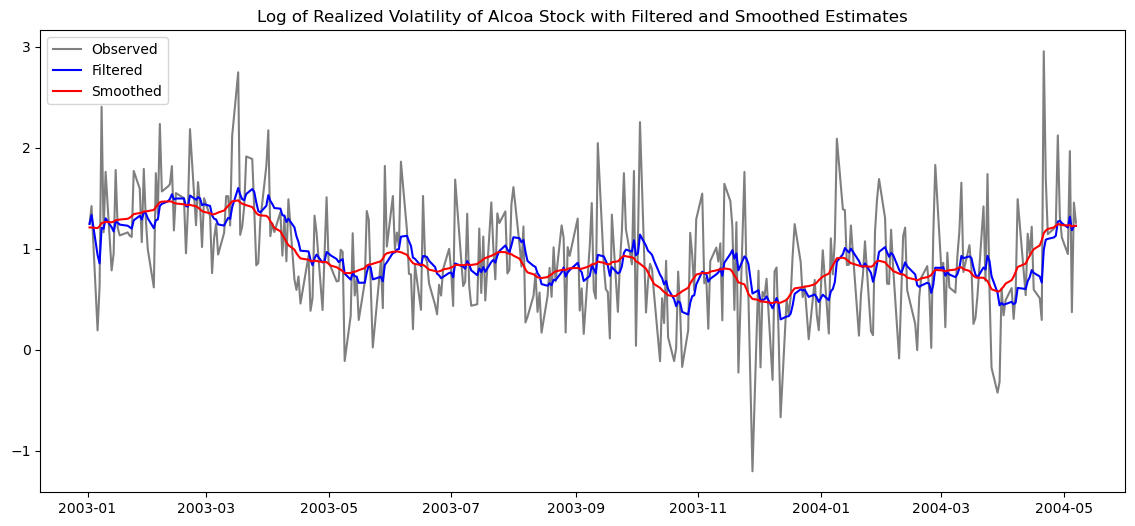

In [39]:
fig, ax = plt.subplots(figsize=(14, 6))

# observed
ax.plot(alcoa.index, alcoa['x'], color='black', label='Observed', alpha=0.5)

# filtered
ax.plot(alcoa.index, alcoa['filtered_state'], color='blue', label='Filtered')

# smoothed
ax.plot(alcoa.index, alcoa['smoothed_state'], color='red', label='Smoothed')

ax.set_title("Log of Realized Volatility of Alcoa Stock with Filtered and Smoothed Estimates")
ax.legend()
plt.show()

In [22]:
# Setting up 95% confidence intervals of filtered and smoothed estimates 

# 95% conf interval = estimate +- 1.96 * standard deviation

alcoa["filtered_95_ci_upper"] = alcoa["filtered_state"] + 1.96*np.sqrt(alcoa["filtered_var"])
alcoa["filtered_95_ci_lower"] = alcoa["filtered_state"] - 1.96*np.sqrt(alcoa["filtered_var"])


alcoa["smoothed_95_ci_upper"] = alcoa["smoothed_state"] + 1.96*np.sqrt(alcoa["smoothed_var"])
alcoa["smoothed_95_ci_lower"] = alcoa["smoothed_state"] - 1.96*np.sqrt(alcoa["smoothed_var"])

alcoa.head()

,x,filtered_state,filtered_var,smoothed_state,smoothed_var,filtered_95_ci_upper,filtered_95_ci_lower,smoothed_95_ci_upper,smoothed_95_ci_lower
2003-01-02,1.245451,1.245450,0.230684,1.210890,0.032711,2.186830,0.304070,1.565379,0.856401
2003-01-03,1.422385,1.334942,0.116678,1.210080,0.028730,2.004441,0.665443,1.542301,0.877860
2003-01-06,0.192602,0.939611,0.079833,1.204296,0.025799,1.493404,0.385817,1.519110,0.889483
2003-01-07,0.627168,0.855311,0.062240,1.222216,0.023639,1.344292,0.366331,1.523567,0.920865
2003-01-08,2.405115,1.206724,0.052307,1.254077,0.022049,1.654989,0.758458,1.545115,0.963040


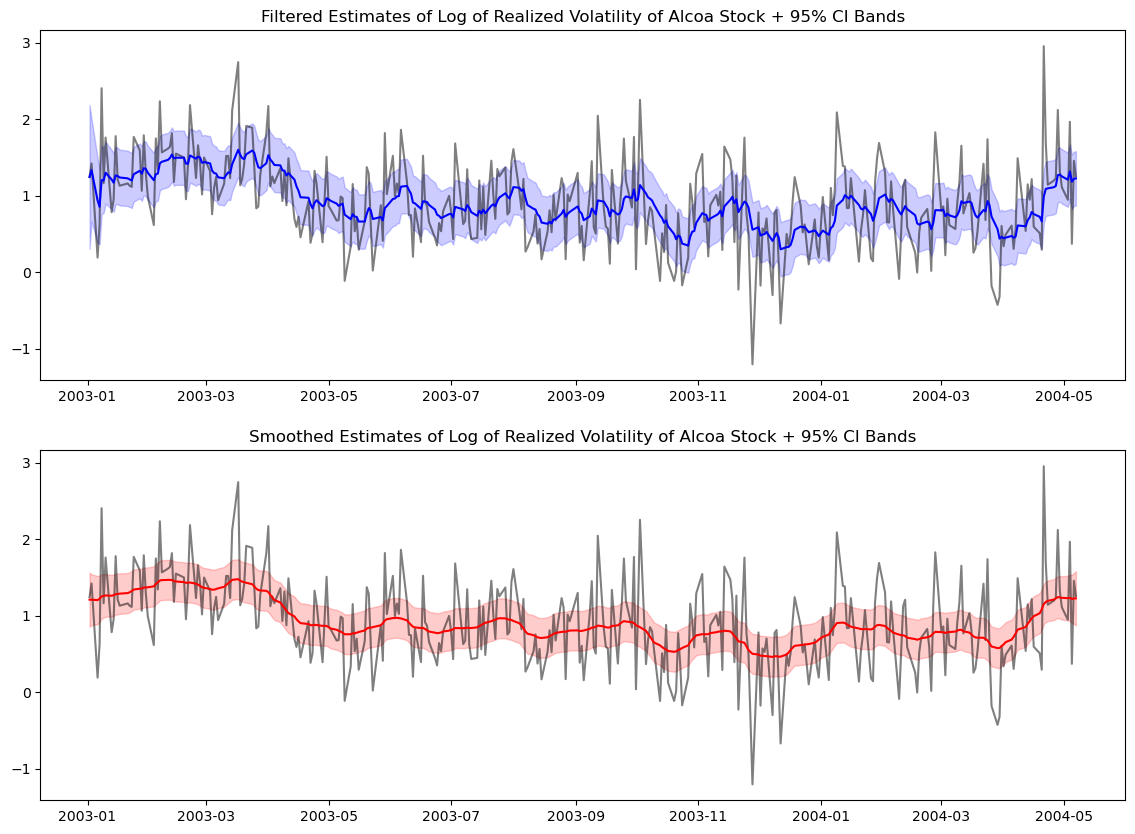

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))


# observed
ax1.plot(alcoa.index, alcoa['x'], color='black', label='Observed', alpha=0.5)

# filtered
ax1.plot(alcoa.index, alcoa['filtered_state'], color='blue', label='Filtered')
ax1.fill_between(alcoa.index, 
                alcoa['filtered_95_ci_lower'], 
                alcoa['filtered_95_ci_upper'], 
                color='blue', alpha=0.2);
ax1.set_title("Filtered Estimates of Log of Realized Volatility of Alcoa Stock + 95% CI Bands")

# observed
ax2.plot(alcoa.index, alcoa['x'], color='black', label='Observed', alpha=0.5)
# smoothed
ax2.plot(alcoa.index, alcoa['smoothed_state'], color='red', label='Smoothed')
ax2.fill_between(alcoa.index, alcoa['smoothed_95_ci_lower'], alcoa['smoothed_95_ci_upper'], 
                color='red', alpha=0.2);
ax2.set_title("Smoothed Estimates of Log of Realized Volatility of Alcoa Stock + 95% CI Bands")

plt.show()

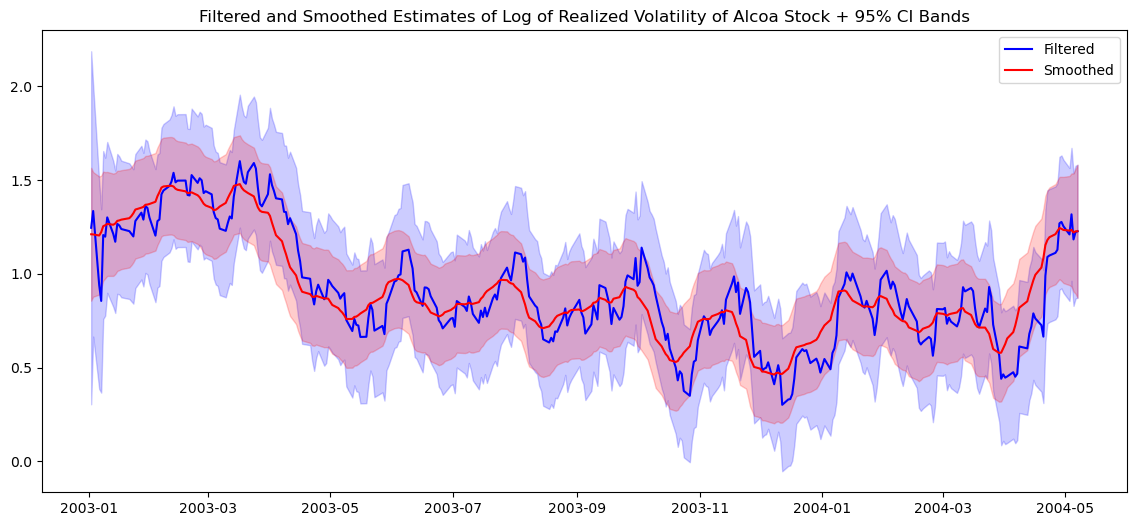

In [24]:
fig, ax = plt.subplots(figsize=(14, 6))

# observed
# ax.plot(alcoa.index, alcoa['x'], color='black', label='Observed', alpha=0.5)

# filtered
ax.plot(alcoa.index, alcoa['filtered_state'], color='blue', label='Filtered')
ax.fill_between(alcoa.index, 
                alcoa['filtered_95_ci_lower'], 
                alcoa['filtered_95_ci_upper'], 
                color='blue', alpha=0.2);
# smoothed
ax.plot(alcoa.index, alcoa['smoothed_state'], color='red', label='Smoothed')
ax.fill_between(alcoa.index, alcoa['smoothed_95_ci_lower'], alcoa['smoothed_95_ci_upper'], 
                color='red', alpha=0.2)

ax.set_title("Filtered and Smoothed Estimates of Log of Realized Volatility of Alcoa Stock + 95% CI Bands")
ax.legend()
plt.show()

### Step 6: Let's Do Some Prediction 

To predict $h$ time steps forward, the process is quite simple.

Normally, we would run our filter at each time step, taking in the observation at that point $y_t$ and computing $v, V, K$ to get our estimates $\mu_{t|t}$ and $\Sigma_{t|t}$, and then running our predict step to find $\mu_{t+1|t}$ and $\Sigma_{t+1|t}$

However, for predicting $y$ at $h$ steps ahead, we have no observation $y_{T+h}$ to input. Thus, we skip the entire estimation step--our estimates are not updated because there's no observation to change our beliefs--and only run our predict steps $h$ times. 

So for one step ahead, we simply run: 

- $\mu_{T + 1|T} = \mu_{T|T}$
- $\Sigma_{T + 1|T} = \Sigma_{T|T} + \sigma^2_{\eta}$

(notice the estimate $\mu$ doesn't change, it just gets carried forward, and the variance $\Sigma$ adds a transition noise term). 

And for $h$ steps ahead, our Kalman recursion simplifies to: 

- $\mu_{T + h|T} = \mu_{T|T}$
- $\Sigma_{T + h|T} = \Sigma_{T|T} + h * \sigma^2_{\eta}$

(our estimate stays the same as what it was when we last had an observation and our variance increases linearly with each step) 


Now we have a belief about where the hidden state $\mu$ will be at time $T+h$, given all data up to $T$. But you can't observe $\mu$, only $y$ so we need to use the observation equation:

$$y_{T+h} = \mu_{T+h} + e_{T+h} $$ 

So our forecast of $y$ is:

- $\hat{y}_{T+h} = E(\mu_{T+h}) + E(e_{T+h}) = \mu_{T+h|T} + 0 = \mu_{T+h|T}$

and innovation/forecast error and variance of forecast error (how uncertain we are of $y_t$ given $\mu$) are: 

- $v_{T+h} = y_{T+h} - \hat{y}_{T+h} = (\mu_{T+h} + e_{T+h}) - \mu_{T+h|T}$
    
    $= (\mu_{T+h} - \mu_{T+h|T}) + e_{T+h}$

- $V_{T+h} = Var(y_{T+h} - \hat{y}_{T+h}) = Var(\mu_{T+h} - \mu_{T+h|T}) + Var(e_{T+h})$

    $= Var(\mu_{T+h} \mid y_1, \dots, y_T) + \sigma_e^2$

  $= \Sigma_{T+h|T} + \sigma_e^2$


Plugging in $\mu_{T + h|T}$ and $\Sigma_{T+h|T}$, our h-step forecast of $y$ is 

- $\hat{y}_{T+h} = \mu_{T|T}$

    with forecast error variance
- $V_{T+h} = \Sigma_{T|T} + h\sigma^2_{\eta} + \sigma_e^2$


Let's try to predict 10 steps ahead. 

In [25]:
# get last state estimate + var at time t = T 

last_mu = mu[-1]
last_sig = sig[-1]

mu_10_preds = [last_mu]
sig_10_preds = [last_sig]


# Run our Kalman Filter (just predict steps) 10 steps ahead
h = 10

for t in range(1,h+1): 

    # prediction of state one step ahead

    mu_pred_t = mu_10_preds[t-1]
    mu_10_preds.append(mu_pred_t)

    
    # prediction of state variance one step ahead
    sig_pred_t = sig_10_preds[t-1]+ sigma_eta_squared
    sig_10_preds.append(sig_pred_t)
    

In [26]:
mu_10_preds

[1.227144114247882,
 1.227144114247882,
 1.227144114247882,
 1.227144114247882,
 1.227144114247882,
 1.227144114247882,
 1.227144114247882,
 1.227144114247882,
 1.227144114247882,
 1.227144114247882,
 1.227144114247882]

In [27]:
sig_10_preds

[0.03271101388799999,
 0.038115839999999984,
 0.04352066611199998,
 0.04892549222399997,
 0.054330318335999966,
 0.05973514444799996,
 0.06513997055999995,
 0.07054479667199995,
 0.07594962278399994,
 0.08135444889599994,
 0.08675927500799993]

So our state estimate and variance at $T+h$ are 

In [28]:
print(mu_10_preds[-1])
print(sig_10_preds[-1])

1.227144114247882
0.08675927500799993


Lets find our forecast $\hat{y}_{T+h}$

In [29]:
y_t_h = mu_10_preds[-1] 
V_t_h = sig_10_preds[-1] + sigma_e_squared

print(y_t_h)
print(V_t_h) 

# could have also found each without explicitly running the Filter 
y_t_h = last_mu 
V_t_h = last_sig + h*sigma_eta_squared + sigma_e_squared

print(y_t_h)
print(V_t_h)


1.227144114247882
0.3174434350079999
1.227144114247882
0.3174434350079999


### Step 7: Plotting our Forecasts

We first need to find y's forecast estimates and variance of forecast error for all time steps up to $T + h$, which is easy because we ran the filter (predict step only) up to time step h. 

In [30]:
y_forecasts = mu_10_preds[1:]
V_forecasts = [sig + sigma_e_squared for sig in sig_10_preds[1:]]

In [31]:
# set up 95% CI bands
upper = np.array(y_forecasts) + 1.96 * np.sqrt(V_forecasts)
lower = np.array(y_forecasts) - 1.96 * np.sqrt(V_forecasts)

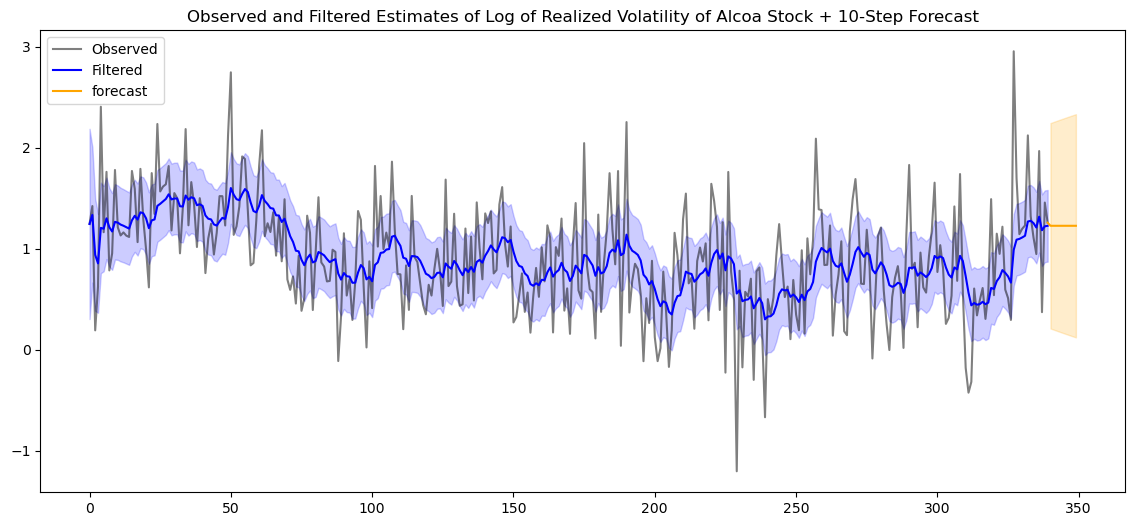

In [36]:
T = len(y)
forecast_index = range(T, T + h)

fig, ax = plt.subplots(figsize=(14, 6))

# observed
ax.plot(range(T), alcoa['x'], color='black', label='Observed', alpha=0.5)

# filtered
ax.plot(range(T), alcoa['filtered_state'], color='blue', label='Filtered')
ax.fill_between(range(T), 
                alcoa['filtered_95_ci_lower'], 
                alcoa['filtered_95_ci_upper'], 
                color='blue', alpha=0.2)
# forecast
ax.plot([T-1] + list(forecast_index), [y.iloc[-1]] + y_forecasts, 
         label='forecast', color='orange')
# confidence bands
ax.fill_between(forecast_index, 
                lower, 
                upper, 
                color='orange', alpha=0.2)

ax.set_title("Observed and Filtered Estimates of Log of Realized Volatility of Alcoa Stock + 10-Step Forecast")
ax.legend()
plt.show()

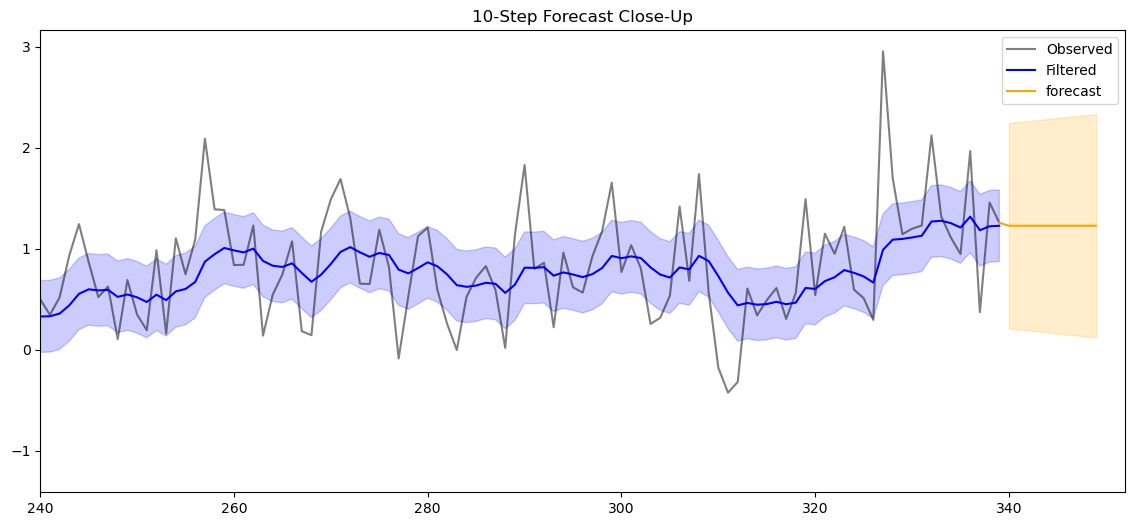

In [37]:
# zoom in on last 100 observations

fig, ax = plt.subplots(figsize=(14, 6))

# observed
ax.plot(range(T), alcoa['x'], color='black', label='Observed', alpha=0.5)

# filtered
ax.plot(range(T), alcoa['filtered_state'], color='blue', label='Filtered')
ax.fill_between(range(T), 
                alcoa['filtered_95_ci_lower'], 
                alcoa['filtered_95_ci_upper'], 
                color='blue', alpha=0.2)
# forecast
ax.plot([T-1] + list(forecast_index), [y.iloc[-1]] + y_forecasts, 
         label='forecast', color='orange')
# confidence bands
ax.fill_between(forecast_index, 
                lower, 
                upper, 
                color='orange', alpha=0.2)

ax.set_xlim(T - 100, T + h + 2)

ax.set_title("10-Step Forecast Close-Up")
ax.legend()
plt.show()

Here we can see clearly how the Kalman prediction works for our local trend model:

- our forecast of $y_{T+h}$ remains the same as our last state estimate when we had access to observations
- our variance of forecast error grows linearly, as it our uncertainty (Var) of our state estimate $\Sigma_{T|T}$ + transition error gained with each time step $h\sigma^2_{\eta}$ + measurement error $\sigma_e^2$
    - because of this our forecast error is much larger than our filtered values' uncertainty (which is just the state estimate uncertainty $\Sigma_{t|t}$)

Obviously, our Kalman prediction for the local trend model is not very useful. 

But the value of the Kalman filter is not in prediction but in its other applications, such as dealing with missing values (same mechanism as prediction: skipping update steps and only predicting on missing time steps) and state estimation--recovering the smoothed hidden state trajectory $\mu_{1|T}, \ldots \mu_{T|T}$ from noisy observations, which is the core use case for applications like nowcasting macroeconomic indicators from high-frequency data. 

Next we'll explore beyond the local trend model and look at the Kalman filter/smoother for general multivariate state-space models.